
# Анализ опроса об учебной автономии

Этот ноутбук предназначен для:
- загрузки файла с результатами опроса (Excel);
- построения параметров автономии (15 бинарных признаков);
- расчёта описательной статистики, также и расчета Альфа Кронбаха;
- сравнения онлайн / офлайн-групп (χ², Cramer's V, t-test / Mann–Whitney);
- факторного анализа параметров автономии;
- визуализация факторного анализи (тепловая карта);




In [ ]:

# ===============================================================
# 0. Установка библиотек
# ===============================================================

!pip install factor_analyzer openpyxl --quiet


In [ ]:

# ===============================================================
# 1. Импорт библиотек и базовые настройки
# ===============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns


from scipy import stats
from factor_analyzer import FactorAnalyzer
from sklearn.preprocessing import LabelBinarizer

pd.set_option('display.max_colwidth', 500)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')



## 1.1. Загрузка данных опроса

Загружаем сюда  Excel-файл с ответами на опрос (Опрос_автономия.xlsx).

In [ ]:

from google.colab import files

uploaded = files.upload("Опрос_автономия.xlsx")
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)
print("Размер данных:", df.shape)
df.head()


Saving Опрос_автономия.xlsx to Опрос_автономия.xlsx/Опрос_автономия.xlsx
Размер данных: (139, 11)


,Отметка времени,"Что в себя включает учебная автономия при изучении иностранного языка? Выберите все подходящие, на ваш взгляд, варианты.",Кто несёт большую ответственность за развитие навыка учебной автономии?,"Как вам кажется, какой формат обучения позволяет учащимся проявлять автономию шире?","За счёт чего, на ваш взгляд, онлайн-среда более способствует расширению автономии в сравнении с очными аудиторными занятиями?","Чем, на ваш взгляд, онлайн-среда уступает очным занятиям в формировании навыка автономии?",В каком формате у вас получается эффективнее развивать автономию учащихся?,У вас есть опыт ведения занятий очно?,У вас есть опыт ведения занятий онлайн?,Вы преподаёте в последнее время ...,Где вы преподаёте?
0,2022-04-13 14:02:14.371,"желание понимать задачи, цели и итоги обучения, рефлексия в процессе обучения, самоконтроль и отслеживание прогресса, желание всегда получать обратную связь и комментарии на выполненные задания, работа над ошибками, самокоррекция, активное общение с преподавателем (на занятии, в чате, по почте) по учебным вопросам, использование различных учебных ресурсов (словарей, языкового корпуса, специальных сайтов, посвящённых языку и т.п.), самостоятельное привлечение дополнительных материалов, окруже...",равная ответственность учащегося и преподавателя,онлайн-среда,Возможность самостоятельного подбора материалов. Изучение с помощью контента (+на интересующую тему),-,в онлайн-среде,да,да,в основном онлайн,"частные уроки, Разговорный клуб"
1,2022-04-13 16:03:46.318,"способность правильно организовывать время, желание понимать задачи, цели и итоги обучения, рефлексия в процессе обучения, самостоятельное привлечение дополнительных материалов, проявление интереса не только к самому языку, но и культуре, традициям, истории страны изучаемого языка, окружение себя языком (интерфейс гаджетов и сервисов, кино, видео, музыка, радио, подкасты, новости, книги – всё на изучаемом языке), участие в языковом клубе и поиск собеседников, общение с носителями языка, изуч...",равная ответственность учащегося и преподавателя,онлайн-среда,"количество времени, интересы и актуальность",Нет,в онлайн-среде,да,да,в основном онлайн,частные уроки
2,2022-04-13 18:23:18.315,"способность правильно организовывать время, ограждение себя от всего, что отвлекает и мешает учиться, желание понимать задачи, цели и итоги обучения, рефлексия в процессе обучения, самоконтроль и отслеживание прогресса, ответственное выполнение заданий, работа над ошибками, самокоррекция, ведение словаря, тетради с правилами и т.п. исключительно для себя, а не ради оценки",равная ответственность учащегося и преподавателя,"Затрулняюсь ответить, кажется, важен не формат, а то,как препод учит студента автономии.","Можно прибегать в самостоятельному поиску информации,если лень писать преподавателю.",-,"одинаковые результаты, что онлайн, что очно",да,да,в основном очно,университет
3,2022-04-13 19:31:55.172,"самоконтроль и отслеживание прогресса, вознаграждение себя за успехи, порядок и аккуратность в учебных материалах, ответственное выполнение заданий, работа над ошибками, самокоррекция, активное общение с преподавателем (на занятии, в чате, по почте) по учебным вопросам, самостоятельное привлечение дополнительных материалов, проявление интереса не только к самому языку, но и культуре, традициям, истории страны изучаемого языка, окружение себя языком (интерфейс гаджетов и сервисов, кино, видео...",учащийся,онлайн-среда,"Во время онлайн обучения происходит расширение автономии, так как в таком случае на студента возлагается бОльшая ответственность за выполнение самостоятельной работы, так как преподаватель не может проконтролировать её выполнение и повлиять на студента ""напрямую"". Также студенты всегда могут сослаться на плохую связь и интернет, если задание не было выполнено.","Да, так как в аудитории я беру весь контроль на себя и выполнение самостоятельной работы тоже полностью контролируется. Если студент пришел на занятие с невыполненным домашним заданием,


## 1.2. Быстрый осмотр колонок

Посмотрим, какие есть вопросы (названия колонок).

In [ ]:

df.columns.to_list()


['Отметка времени',
 'Что в себя включает учебная автономия при изучении иностранного языка? Выберите все подходящие, на ваш взгляд, варианты.',
 'Кто несёт большую ответственность за развитие навыка учебной автономии?',
 'Как вам кажется, какой формат обучения позволяет учащимся проявлять автономию шире?',
 'За счёт чего, на ваш взгляд, онлайн-среда более способствует расширению автономии в сравнении с очными аудиторными занятиями?',
 'Чем, на ваш взгляд, онлайн-среда уступает очным занятиям в формировании навыка автономии?',
 'В каком формате у вас получается эффективнее развивать автономию учащихся?',
 'У вас есть опыт ведения занятий очно?',
 'У вас есть опыт ведения занятий онлайн?',
 'Вы преподаёте в последнее время ...',
 'Где вы преподаёте?']


## 2. Настройка основных колонок

Здесь мы находим:
- колонку с вопросом про **«Что включает учебная автономия…»** (множественный выбор);
- колонку с форматом преподавания (онлайн / офлайн);



In [ ]:

# Находим нужные колонки
autonomy_cols = [c for c in df.columns if 'учебная автономия' in c]
format_cols = [c for c in df.columns if 'преподаёте в последнее время' in c or 'преподаете в последнее время' in c]

print("Колонки, которые выглядят как вопросы про автономию:")
print(autonomy_cols)

print("\nКолонки, которые похожи на формат преподавания онлайн/очно:")
print(format_cols)

# === ВАЖНО ===
# 1) отбираем ОДНУ колонку с множественным выбором про автономию:
autonomy_col = autonomy_cols[0]
print("\nИспользуем колонку про автономию:", autonomy_col)

# 2) Отбираем колонку с форматом преподавания (в основном онлайн / в основном очно):
format_col = format_cols[0]
print("Используем колонку про формат:", format_col)


Колонки, которые выглядят как вопросы про автономию:
['Что в себя включает учебная автономия при изучении иностранного языка? Выберите все подходящие, на ваш взгляд, варианты.']

Колонки, которые похожи на формат преподавания онлайн/очно:
['Вы преподаёте в последнее время ...']

Используем колонку про автономию: Что в себя включает учебная автономия при изучении иностранного языка? Выберите все подходящие, на ваш взгляд, варианты.
Используем колонку про формат: Вы преподаёте в последнее время ...


Альфа Кронбаха

In [ ]:
# Преобразуем эту колонку в 0/1 по каждому параметру

# 1. Получаем список всех уникальных параметров
all_autonomy_options = df[autonomy_col].dropna().str.split(';|,').explode().str.strip().unique()

# 2. Создадим по одной колонке на каждый параметр
for option in all_autonomy_options:
    df[option] = df[autonomy_col].fillna('').apply(lambda x: int(option in x))

# 3. Соберём эти 0/1 колонки в отдельный датафрейм
autonomy_matrix = df[list(all_autonomy_options)]

# 4. Функция для подсчёта альфы Кронбаха
def cronbach_alpha(df_bin):
    itemscores = df_bin.to_numpy()
    itemvars = itemscores.var(axis=0, ddof=1)
    tscores = itemscores.sum(axis=1)
    nitems = df_bin.shape[1]
    return (nitems / (nitems - 1)) * (1 - itemvars.sum() / tscores.var(ddof=1))

# 5. Считаем альфу
alpha = cronbach_alpha(autonomy_matrix)
print(f"\nАльфа Кронбаха по всем параметрам автономии: {alpha:.3f}")



Альфа Кронбаха по всем параметрам автономии: 0.908



## 3. Формирование переменной `format_group` (online / offline)

Мы сведём варианты ответов к более простым категориям:
- `"online"` — в основном онлайн;
- `"offline"` — в основном очно;
- `"mixed"` / `"other"` / `"no_teaching"` — если что-то не подходит под чистый онлайн/офлайн.


In [ ]:

def map_format(value):
    if pd.isna(value):
        return np.nan
    v = str(value).strip().lower()

    # равномерно и т.п.
    if 'равномерно' in v or 'поровну' in v:
        return 'mixed'

    # онлайн без очного
    if 'онлайн' in v and 'очно' not in v:
        return 'online'

    # очно без онлайна
    if 'очно' in v and 'онлайн' not in v:
        return 'offline'

    # варианты "не преподаю"
    if 'не преподаю' in v or 'без работы' in v:
        return 'no_teaching'

    return 'other'

df['format_group'] = df[format_col].apply(map_format)

df['format_group'].value_counts(dropna=False)


,count
format_group,
online,53
offline,44
mixed,37
no_teaching,4
NaN,1


In [ ]:
# Оставляем только чистые онлайн/офлайн для сравнений
df_fo = df[df['format_group'].isin(['online', 'offline'])].copy()
df_fo['format_group'].value_counts()


,count
format_group,
online,53
offline,44



## 4. Параметры автономии: 15 бинарных признаков

Здесь мы строим 15 параметров автономии, основываясь на формулировках в Опросе.



In [ ]:
df[autonomy_col].head()

,"Что в себя включает учебная автономия при изучении иностранного языка? Выберите все подходящие, на ваш взгляд, варианты."
0,"желание понимать задачи, цели и итоги обучения, рефлексия в процессе обучения, самоконтроль и отслеживание прогресса, желание всегда получать обратную связь и комментарии на выполненные задания, работа над ошибками, самокоррекция, активное общение с преподавателем (на занятии, в чате, по почте) по учебным вопросам, использование различных учебных ресурсов (словарей, языкового корпуса, специальных сайтов, посвящённых языку и т.п.), самостоятельное привлечение дополнительных материалов, окруже..."
1,"способность правильно организовывать время, желание понимать задачи, цели и итоги обучения, рефлексия в процессе обучения, самостоятельное привлечение дополнительных материалов, проявление интереса не только к самому языку, но и культуре, традициям, истории страны изучаемого языка, окружение себя языком (интерфейс гаджетов и сервисов, кино, видео, музыка, радио, подкасты, новости, книги – всё на изучаемом языке), участие в языковом клубе и поиск собеседников, общение с носителями языка, изуч..."
2,"способность правильно организовывать время, ограждение себя от всего, что отвлекает и мешает учиться, желание понимать задачи, цели и итоги обучения, рефлексия в процессе обучения, самоконтроль и отслеживание прогресса, ответственное выполнение заданий, работа над ошибками, самокоррекция, ведение словаря, тетради с правилами и т.п. исключительно для себя, а не ради оценки"
3,"самоконтроль и отслеживание прогресса, вознаграждение себя за успехи, порядок и аккуратность в учебных материалах, ответственное выполнение заданий, работа над ошибками, самокоррекция, активное общение с преподавателем (на занятии, в чате, по почте) по учебным вопросам, самостоятельное привлечение дополнительных материалов, проявление интереса не только к самому языку, но и культуре, традициям, истории страны изучаемого языка, окружение себя языком (интерфейс гаджетов и сервисов, кино, видео..."
4,"способность правильно организовывать время, ограждение себя от всего, что отвлекает и мешает учиться, желание понимать задачи, цели и итоги обучения, рефлексия в процессе обучения, самоконтроль и отслеживание прогресса, вознаграждение себя за успехи, ответственное выполнение заданий, работа над ошибками, самокоррекция, использование различных учебных ресурсов (словарей, языкового корпуса, специальных сайтов, посвящённых языку и т.п.), самостоятельное привлечение дополнительных материалов, из..."


In [ ]:
df[autonomy_col].unique()[:100]

array(['желание понимать задачи, цели и итоги обучения, рефлексия в процессе обучения, самоконтроль и отслеживание прогресса, желание всегда получать обратную связь и комментарии на выполненные задания, работа над ошибками, самокоррекция, активное общение с преподавателем (на занятии, в чате, по почте) по учебным вопросам, использование различных учебных ресурсов (словарей, языкового корпуса, специальных сайтов, посвящённых языку и т.п.), самостоятельное привлечение дополнительных материалов, окружение себя языком (интерфейс гаджетов и сервисов, кино, видео, музыка, радио, подкасты, новости, книги – всё на изучаемом языке), общение с носителями языка',
       'способность правильно организовывать время, желание понимать задачи, цели и итоги обучения, рефлексия в процессе обучения, самостоятельное привлечение дополнительных материалов, проявление интереса не только к самому языку, но и культуре, традициям, истории страны изучаемого языка, окружение себя языком (интерфейс гаджетов и серв

In [ ]:
# Словари шаблонов: ключ = параметр, значение = список фраз, которые ищем в ответе.
#
param_patterns = {
    # 1. Осознание целей
    'Осознание целей обучения': [
        'желание понимать задачи, цели и итоги обучения',
        'цели и итоги обучения'
    ],

    # 2. Планирование времени и концентрация
    'Организация учебного времени и управление вниманием': [
        'способность правильно организовывать время',
        'правильно организовывать время',
        'ограждение себя от всего, что отвлекает и мешает учиться',
        'от всего, что отвлекает и мешает учиться'
    ],

    # 3. Организация учебных материалов и заданий
    'Организация учебных материалов и заданий': [
        'ответственное выполнение заданий',
        'порядок и аккуратность в учебных материалах',
        'порядок и аккуратность в учебных',
        'ведение словаря, тетради с правилами и т.п. исключительно для себя, а не ради оценки',
        'тетради с правилами и т.п. исключительно для себя'
    ],

    # 4. Самоконтроль / мониторинг и рефлексия
    'Саморегуляция': [
        'самоконтроль и отслеживание прогресса',
        'отслеживание прогресса',
        'рефлексия в процессе обучения'
    ],

    # 5. Самооценка / самоподдержка
    'Самоподдержка': [
        'вознаграждение себя за успехи',
        'готовность и умение ее анализировать, совершенствовать собственные навыки на основе обратной связи',
        'совершенствовать собственные навыки на основе обратной связи'
    ],

    # 6. Выбор стратегий и содержания обучения
    'Выбор стратегий обучения': [
        'изучение того, что интересно и не входит в учебную программу, на иностранном языке',
        'то, что интересно и не входит в учебную программу',
        'самостоятельное привлечение дополнительных материалов'
    ],

    # 7. Использование учебных ресурсов
    'Использование учебных ресурсов': [
        'использование различных учебных ресурсов (словарей, языкового корпуса, специальных сайтов, посвящённых языку и т.п.)',
        'различных учебных ресурсов (словарей, языкового корпуса, специальных сайтов'
    ],

    # 8. Инициативность и дополнительная активность
    'Инициативная учебная активность': [
        'самостоятельное привлечение дополнительных материалов',
        'участие в языковом клубе и поиск собеседников',
        'участие во внеаудиторных программах на изучаемом языке (поход в музей, на экскурсию и пр.)',
        'участие во внеаудиторных программах на изучаемом языке'
    ],

    # 9. Общая учебная мотивация / расширенный интерес
    'Общая учебная мотивация': [
        'проявление интереса не только к самому языку, но и культуре, традициям, истории страны изучаемого языка',
        'интереса не только к самому языку, но и культуре, традициям, истории страны'
    ],

    # 10. Внутренняя мотивация / интерес к языку
    'Внутренняя мотивация': [
        'изучение того, что интересно и не входит в учебную программу, на иностранном языке',
        'то, что интересно и не входит в учебную программу',
        'окружение себя языком (интерфейс гаджетов и сервисов, кино, видео, музыка, радио, подкасты, новости, книги – всё на изучаемом языке)'
    ],

    # 11. Ответственность
    'Ответственность': [
        'ответственное выполнение заданий'
    ],

    # 12. Преодоление трудностей
    'Преодоление учебных трудностей': [
        'ограждение себя от всего, что отвлекает и мешает учиться'
    ],

    # 13. Взаимодействие с преподавателем и работа с обратной связью
    'Взаимодействие с преподавателем': [
        'активное общение с преподавателем (на занятии, в чате, по почте) по учебным вопросам',
        'активное общение с преподавателем (на занятии, в чате, по почте)',
        'желание всегда получать обратную связь и комментарии на выполненные задания',
        'обратную связь и комментарии на выполненные задания',
        'готовность и умение ее анализировать, совершенствовать собственные навыки на основе обратной связи',
        'анализировать, совершенствовать собственные навыки на основе обратной связи'
    ],

    # 14. Социальное взаимодействие и учебное сообщество
    'Социальное взаимодействие в обучении': [
        'участие в языковом клубе и поиск собеседников',
        'поиск собеседников',
        'общение с носителями языка',
        'участие во внеаудиторных программах на изучаемом языке (поход в музей, на экскурсию и пр.)',
        'участие во внеаудиторных программах на изучаемом языке'
    ],

    # 15. Цифровая автономия / языковая среда через технологии
    'Использование цифровой языковой среды': [
        'окружение себя языком (интерфейс гаджетов и сервисов, кино, видео, музыка, радио, подкасты, новости, книги – всё на изучаемом языке)',
        'интерфейс гаджетов и сервисов',
        'кино, видео, музыка, радио, подкасты, новости, книги – всё на изучаемом языке'
    ]
}

len(param_patterns)


15

In [ ]:

def extract_param_flags(text, patterns_dict):
    text = str(text).lower()
    flags = {}
    for param, patterns in patterns_dict.items():
        flags[param] = int(any(p in text for p in patterns))
    return flags

param_df = df[autonomy_col].fillna('').apply(
    lambda x: pd.Series(extract_param_flags(x, param_patterns))
)

param_df.head()


,Осознание целей обучения,Организация учебного времени и управление вниманием,Организация учебных материалов и заданий,Саморегуляция,Самоподдержка,Выбор стратегий обучения,Использование учебных ресурсов,Инициативная учебная активность,Общая учебная мотивация,Внутренняя мотивация,Ответственность,Преодоление учебных трудностей,Взаимодействие с преподавателем,Социальное взаимодействие в обучении,Использование цифровой языковой среды
0,1,0,0,1,0,1,1,1,0,1,0,0,1,1,1
1,1,1,0,1,0,1,0,1,1,1,0,0,0,1,1
2,1,1,1,1,0,0,0,0,0,0,1,1,0,0,0
3,0,0,1,1,1,1,0,1,1,1,1,0,1,1,1
4,1,1,1,1,1,1,1,1,0,1,1,1,1,0,0


In [ ]:
# Добавляем бинарные параметры в основной датафрейм
for col in param_df.columns:
    df[col] = param_df[col]
    df_fo[col] = param_df.loc[df_fo.index, col]

param_cols = list(param_patterns.keys())
df[param_cols].sum()

,0
Осознание целей обучения,74
Организация учебного времени и управление вниманием,96
Организация учебных материалов и заданий,102
Саморегуляция,117
Самоподдержка,31
Выбор стратегий обучения,106
Использование учебных ресурсов,65
Инициативная учебная активность,105
Общая учебная мотивация,61
Внутренняя мотивация,111



## 5. Описательная статистика по параметрам автономии

Здесь формируется таблица с частотами и процентами респондентов, выбравших каждый параметр.


In [ ]:
overall_stats = pd.DataFrame({
    'param': param_cols,
    'n': df[param_cols].sum().values,
    'percent': (df[param_cols].mean().values * 100).round(1)
}).sort_values('percent', ascending=False).reset_index(drop=True)

overall_stats


,param,n,percent
0,Саморегуляция,117,84.200
1,Внутренняя мотивация,111,79.900
2,Выбор стратегий обучения,106,76.300
3,Инициативная учебная активность,105,75.500
4,Организация учебных материалов и заданий,102,73.400
5,Организация учебного времени и управление вниманием,96,69.100
6,Социальное взаимодействие в обучении,84,60.400
7,Использование цифровой языковой среды,81,58.300
8,Осознание целей обучения,74,53.200
9,Использование учебных ресурсов,65,46.800


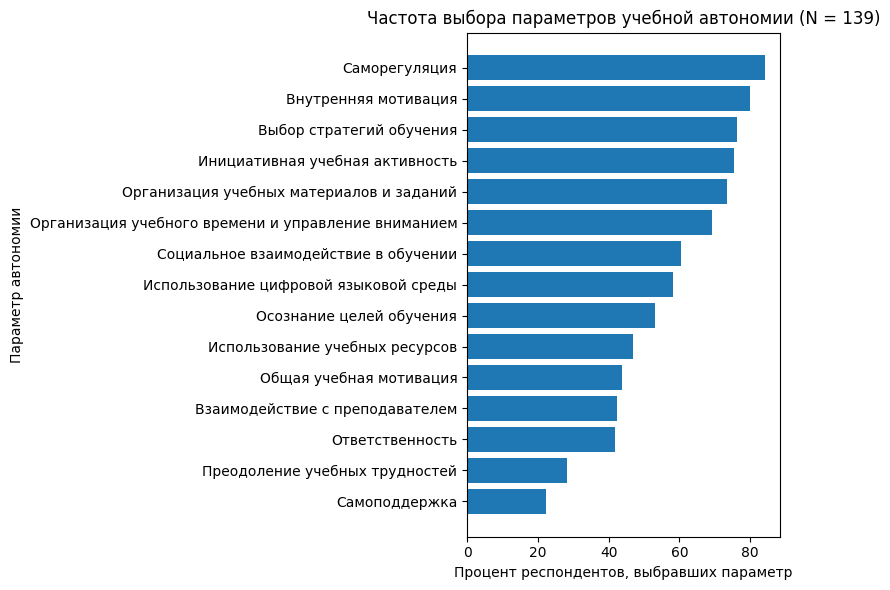

In [ ]:
# Горизонтальная столбчатая диаграмма
plt.figure(figsize=(8, 6))
plt.barh(overall_stats['param'], overall_stats['percent'])
plt.xlabel('Процент респондентов, выбравших параметр')
plt.ylabel('Параметр автономии')
plt.title('Частота выбора параметров учебной автономии (N = {})'.format(len(df)))
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('figure1_autonomy_freq.png', dpi=300, bbox_inches='tight')
plt.show()



## 6. Сравнение онлайн vs офлайн по параметрам автономии

Используем χ²-тест независимости и считаем Cramer's V для оценки размера эффекта.


In [ ]:

group_stats = []

for param in param_cols:
    ctab = pd.crosstab(df_fo['format_group'], df_fo[param])

    if ctab.shape == (2, 2):
        chi2, p, dof, exp = stats.chi2_contingency(ctab)
        n = ctab.values.sum()
        cramer_v = np.sqrt(chi2 / (n * (min(ctab.shape)-1)))
    else:
        chi2, p, cramer_v = np.nan, np.nan, np.nan

    online_n = ctab.loc['online', 1] if ('online' in ctab.index and 1 in ctab.columns) else 0
    offline_n = ctab.loc['offline', 1] if ('offline' in ctab.index and 1 in ctab.columns) else 0
    online_total = ctab.loc['online'].sum() if 'online' in ctab.index else np.nan
    offline_total = ctab.loc['offline'].sum() if 'offline' in ctab.index else np.nan

    group_stats.append({
        'param': param,
        'online_n': online_n,
        'offline_n': offline_n,
        'online_%': (online_n / online_total * 100).round(1) if online_total > 0 else np.nan,
        'offline_%': (offline_n / offline_total * 100).round(1) if offline_total > 0 else np.nan,
        'chi2': chi2,
        'p_value': p,
        "cramers_v": cramer_v
    })

group_stats_df = pd.DataFrame(group_stats).sort_values('p_value')
group_stats_df


,param,online_n,offline_n,online_%,offline_%,chi2,p_value,cramers_v
13,Социальное взаимодействие в обучении,36,22,67.900,50.000,2.511,0.113,0.161
14,Использование цифровой языковой среды,37,23,69.800,52.300,2.435,0.119,0.158
0,Осознание целей обучения,32,19,60.400,43.200,2.203,0.138,0.151
6,Использование учебных ресурсов,27,15,50.900,34.100,2.137,0.144,0.148
10,Ответственность,24,13,45.300,29.500,1.901,0.168,0.140
2,Организация учебных материалов и заданий,41,30,77.400,68.200,0.617,0.432,0.080
9,Внутренняя мотивация,45,34,84.900,77.300,0.491,0.484,0.071
5,Выбор стратегий обучения,41,31,77.400,70.500,0.292,0.589,0.055
11,Преодоление учебных трудностей,19,13,35.800,29.500,0.194,0.660,0.045
12,Взаимодействие с преподавателем,23,17,43.400,38.600,0.071,0.790,0.027


In [ ]:
# Только значимые различия (p < 0.05)
significant_params = group_stats_df[group_stats_df['p_value'] < 0.05]
significant_params

,param,online_n,offline_n,online_%,offline_%,chi2,p_value,cramers_v


Вывод: нет ни одного p < 0.05

Проверим

In [ ]:
group_stats_df['p_value'].min()

0.11308206146639246


## 7. Количество выбранных параметров автономии на человека

Считаем, сколько параметров в среднем выбирают преподаватели онлайн и офлайн, и проверяем значимость различий.


In [ ]:

df_fo['param_count'] = df_fo[param_cols].sum(axis=1)
df_fo.groupby('format_group')['param_count'].describe()


,count,mean,std,min,25%,50%,75%,max
format_group,,,,,,,,
offline,44.000,7.864,2.673,3.000,6.000,7.000,10.250,12.000
online,53.000,9.094,2.452,4.000,8.000,9.000,10.000,15.000


In [ ]:
online_counts = df_fo.loc[df_fo['format_group']=='online', 'param_count']
offline_counts = df_fo.loc[df_fo['format_group']=='offline', 'param_count']

t_stat, p_t = stats.ttest_ind(online_counts, offline_counts, equal_var=False)
u_stat, p_u = stats.mannwhitneyu(online_counts, offline_counts, alternative='two-sided')

print('t-test: t = {:.2f}, p = {:.4f}'.format(t_stat, p_t))
print('Mann–Whitney: U = {:.2f}, p = {:.4f}'.format(u_stat, p_u))

t-test: t = 2.34, p = 0.0213
Mann–Whitney: U = 1462.50, p = 0.0309


<Figure size 600x500 with 0 Axes>

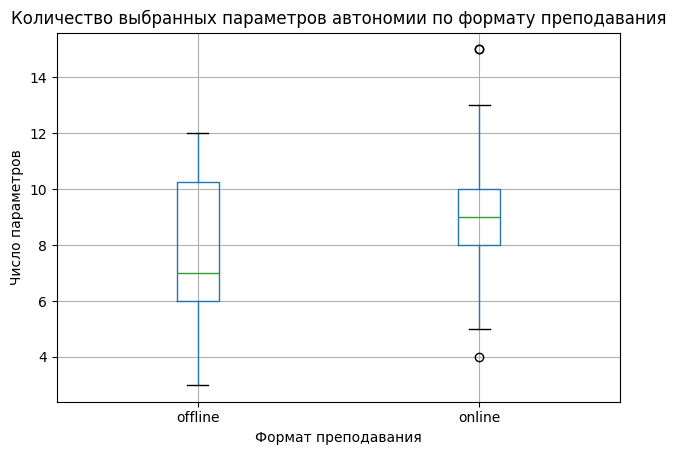

In [ ]:
plt.figure(figsize=(6, 5))
df_fo.boxplot(column='param_count', by='format_group')
plt.title('Количество выбранных параметров автономии по формату преподавания')
plt.suptitle('')
plt.xlabel('Формат преподавания')
plt.ylabel('Число параметров')
plt.tight_layout()
plt.savefig('figure2_param_count_by_format.png', dpi=300, bbox_inches='tight')
plt.show()


## 8. Факторный анализ параметров автономии

Здесь мы проверяем, можно ли выделить несколько факторов (латентных компонентов) в структуре автономии.


In [ ]:
# Берём только тех, у кого хотя бы один параметр отмечен
fa_data = df[param_cols].copy()
fa_data = fa_data.loc[fa_data.sum(axis=1) > 0]

fa_data.shape

from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

chi_square_value, p_value = calculate_bartlett_sphericity(fa_data)

print("Bartlett χ² =", round(chi_square_value, 2))
print("p-value =", p_value)


Bartlett χ² = 456.85
p-value = 2.1609175853988742e-45


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


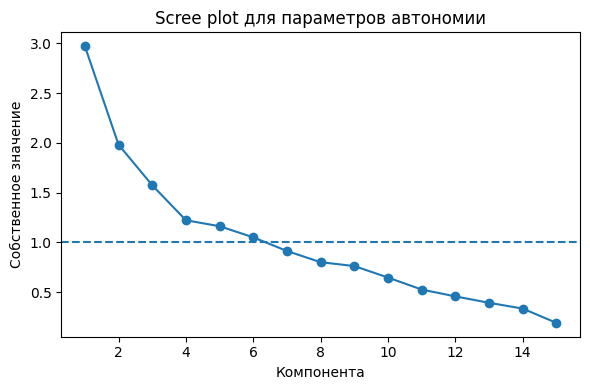

array([2.97246001, 1.98258121, 1.5751534 , 1.22316902, 1.16326243,
       1.05151427, 0.91442158, 0.80154599, 0.76291352, 0.64727832,
       0.5267645 , 0.45805945, 0.39373663, 0.33533576, 0.19180391])

In [ ]:
# Scree plot (собственные значения)
fa = FactorAnalyzer(rotation=None)
fa.fit(fa_data)

ev, v = fa.get_eigenvalues()

plt.figure(figsize=(6, 4))
plt.scatter(range(1, len(ev)+1), ev)
plt.plot(range(1, len(ev)+1), ev)
plt.xlabel('Компонента')
plt.ylabel('Собственное значение')
plt.title('Scree plot для параметров автономии')
plt.axhline(1, linestyle='--')
plt.tight_layout()
plt.savefig('figure3_scree_plot.png', dpi=300, bbox_inches='tight')
plt.show()

ev

In [ ]:
# Выбераем число факторов на основе Scree plot:
n_factors = 4

fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(fa_data)

loadings = pd.DataFrame(
    fa.loadings_,
    index=param_cols,
    columns=[f'factor{i+1}' for i in range(n_factors)]
)

loadings_rounded = loadings.round(2)
loadings_rounded

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,factor1,factor2,factor3,factor4
Осознание целей обучения,-0.140,-0.030,0.390,0.250
Организация учебного времени и управление вниманием,-0.120,0.030,0.050,0.530
Организация учебных материалов и заданий,0.260,0.010,0.100,0.440
Саморегуляция,0.050,0.030,-0.040,0.240
Самоподдержка,0.080,-0.010,0.180,0.280
Выбор стратегий обучения,0.720,0.250,-0.140,0.090
Использование учебных ресурсов,0.220,0.110,0.330,0.130
Инициативная учебная активность,0.800,0.130,0.160,0.010
Общая учебная мотивация,0.110,0.230,0.380,-0.040
Внутренняя мотивация,0.210,0.970,0.070,0.020


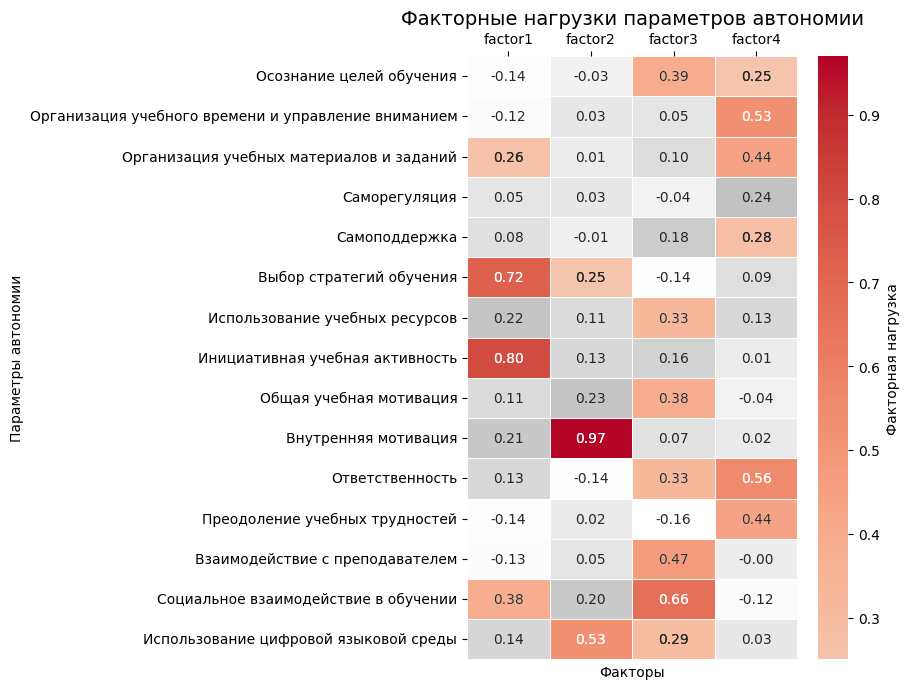

In [ ]:
loadings = loadings_rounded.copy()

# порог значимости
threshold = 0.25

# делаем копию для цветной карты
loadings_color = loadings.copy()

# значения ниже порога заменяем на NaN
loadings_color[np.abs(loadings_color) < threshold] = np.nan

plt.figure(figsize=(9,7))

# сначала рисуем серую основу
sns.heatmap(
    loadings,
    cmap="Greys",
    annot=True,
    fmt=".2f",
    cbar=False
)

# сверху рисуем цветную карту только для значимых
sns.heatmap(
    loadings_color,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Факторная нагрузка"}
)

plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

plt.title("Факторные нагрузки параметров автономии", fontsize=14)
plt.ylabel("Параметры автономии")
plt.xlabel("Факторы")

plt.tight_layout()
plt.show()